In [130]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


(350, 350)


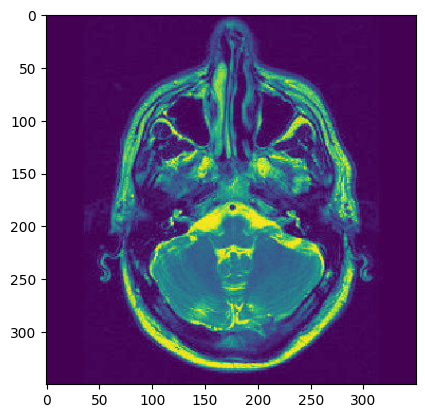

In [131]:
img = cv2.imread("dimag.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = img
print(img.shape)
plt.imshow(img)

In [132]:
seed = (100,200)

In [133]:
seed1 = (100, 150)
seed2 = (200, 250)

In [134]:
def region_growing(img, seed, threshold):

    h, w = img.shape
    seg = np.zeros_like(img)

    seedx, seedy = seed
    seed_val = img[seedy, seedx]

    stack = [(seedx, seedy)]

    while stack:

        x, y = stack.pop()

        if seg[y, x] == 255:
            continue

        if abs(int(img[y, x]) - int(seed_val)) <= threshold:

            seg[y, x] = 255

            for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:

                nx = x + dx
                ny = y + dy

                if 0 <= nx < w and 0 <= ny < h:
                    if seg[ny, nx] == 0:
                        stack.append((nx, ny))

    return seg

In [135]:
region_seed1 = region_growing(img, seed1, 40)
region_seed2 = region_growing(img, seed2, 80)

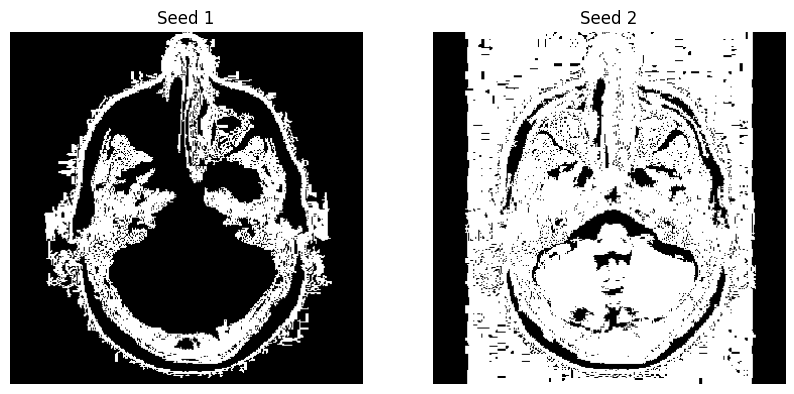

In [136]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(region_seed1, cmap='gray')
plt.title("Seed 1")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(region_seed2, cmap='gray')
plt.title("Seed 2")
plt.axis('off')

plt.show()

In [137]:
print("Seed 1 intensity:", img[seed1[1], seed1[0]])
print("Seed 2 intensity:", img[seed2[1], seed2[0]])

Seed 1 intensity: 44
Seed 2 intensity: 81


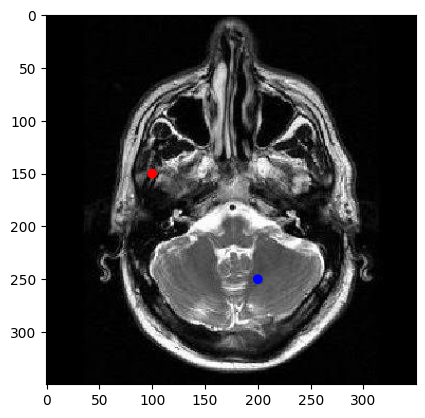

In [138]:
plt.imshow(img, cmap='gray')
plt.scatter(
    [seed1[0], seed2[0]],
    [seed1[1], seed2[1]],
    c=['red', 'blue']
)
plt.show()